# Heat Mitigation Pipeline

End-to-end pipeline: load and reproject a Sentinel-2 patch from Turin, describe the scene with Qwen2.5-VL-3B, then generate heat mitigation suggestions using RAG over EU climate adaptation literature (Qwen2.5-3B-Instruct).

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "/nfs/home/innocenti/heat-mitigation-suggestion/src")

import random
from pathlib import Path
import numpy as np
import rasterio
from rasterio.crs import CRS
from rasterio.warp import calculate_default_transform, reproject, Resampling
from IPython.display import display, Markdown

from heatmit.suggest import _s2_to_rgb, describe_scene
from heatmit.mitigate import RAG, suggest_mitigations

TIF = Path("/nfs/home/innocenti/heat-mitigation-suggestion/turin.tif")
CROP = 224
TARGET_CRS = CRS.from_epsg(32632)
TARGET_RES = 10.0

/nfs/home/innocenti/heat-mitigation-suggestion/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and reproject Turin.tif

In [2]:
with rasterio.open(TIF) as src:
    transform, width, height = calculate_default_transform(
        src.crs, TARGET_CRS, src.width, src.height,
        *src.bounds, resolution=TARGET_RES,
    )
    reprojected = np.zeros((src.count, height, width), dtype=np.float32)
    for band in range(1, src.count + 1):
        reproject(
            source=rasterio.band(src, band),
            destination=reprojected[band - 1],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=TARGET_CRS,
            resampling=Resampling.bilinear,
        )

print(f"Reprojected shape: {reprojected.shape} at {TARGET_RES} m/px")

Reprojected shape: (4, 1510, 1565) at 10.0 m/px


## 3. Random crop and RGB preview

Crop: row=1212, col=52 — covers 2.24 km²


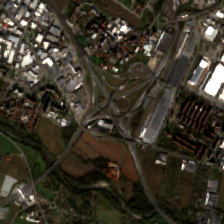

In [3]:
col = random.randint(0, width - CROP)
row = random.randint(0, height - CROP)
patch = reprojected[:, row:row + CROP, col:col + CROP]
s2_patch = np.transpose(patch, (1, 2, 0))  # (H, W, 4)

print(f"Crop: row={row}, col={col} — covers {CROP * TARGET_RES / 1000:.2f} km²")
display(_s2_to_rgb(s2_patch))

## 4. Scene description

In [4]:
description = describe_scene(s2_patch)
display(Markdown(description))

/nfs/home/innocenti/heat-mitigation-suggestion/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights: 100%|██████████| 824/824 [00:01<00:00, 511.98it/s]


The satellite image provided shows a detailed view of the metropolitan area of Turin, northern Italy, covering an area of approximately 1.12 km × 1.12 km. The image has been processed into a true-color RGB composite using bands B04 (Red, 665 nm), B03 (Green, 560 nm), and B02 (Blue, 490 nm).

### Land Cover Types:
1. **Urban Areas**: The image prominently features dense clusters of buildings, roads, and infrastructure. The buildings vary in size and shape, indicating a mix of residential, commercial, and industrial structures.
2. **Green Spaces**: There are patches of greenery, likely parks or gardens, interspersed among the urban areas. These green spaces provide a contrast to the predominantly built-up environment.
3. **Water Bodies**: Small bodies of water, possibly lakes or ponds, are visible near some of the green spaces.

### Urban Morphology:
- **High-Density Urban Areas**: The central part of the image shows high-density urban development with closely packed buildings.
- **Road Networks**: Extensive road networks are evident, including major highways and smaller streets. The roads appear well-defined and organized, suggesting a well-planned urban layout.
- **Intersections and Junctions**: Several intersections and junctions are visible, indicating a complex network of transportation routes.

### Vegetation Presence:
- **Parks and Gardens**: There are several areas with lush green vegetation, likely parks or gardens, providing a natural break from the urban environment.
- **Trees and Bushes**: Scattered trees and bushes are visible, adding to the greenery within the urban landscape.

### Infrastructure:
- **Buildings**: The buildings vary in height and architectural style, indicating a mix of residential, commercial, and industrial structures.
- **Roads and Bridges**: Well-maintained roads and bridges are visible, facilitating easy movement within the city.
- **Utility Lines**: Power lines and other utility infrastructure are also present, indicating the presence of essential services.

### Other Visible Features:
- **Industrial Zones**: Some areas show signs of industrial activity, with taller buildings and possibly factories or warehouses.
- **Residential Areas**: Residential buildings are scattered throughout the image, with varying densities.

### Percentage of Occupation:
- **Urban Areas**: Approximately 70-80% of the image is occupied by urban areas, including buildings, roads, and infrastructure.
- **Green Spaces**: Approximately 10-15% of the image is covered by green spaces such as parks and gardens.
- **Water Bodies**: Approximately 5-10% of the image is occupied by water bodies.

### Type of Buildings:
- **Residential Buildings**: Predominantly low-rise residential buildings, often clustered together.
- **Commercial Buildings**: Medium-rise buildings, likely used for offices, shops, and other commercial purposes.
- **Industrial Buildings**: Taller buildings, possibly factories or warehouses, indicating industrial zones.
- **Public Buildings**: Some larger, more prominent buildings, possibly government or public institutions.

In summary, the image depicts a highly developed urban area with a mix of residential, commercial, and industrial buildings, extensive road networks, and significant green spaces. The high density of buildings and infrastructure suggests a bustling metropolitan area.

## 5. Build RAG index

In [5]:
rag = RAG()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5629.94it/s]


Loading web sources...
  Fetched: https://climate-adapt.eea.europa.eu/en/eu-adaptation-policy/sector-policies/urban/index_html
Loading PDF sources...
  Already downloaded: jrc_eu_cities_heat_extremes.pdf
  Already downloaded: eea_cooling_cities_green_roofs.pdf
  Already downloaded: jrc_green_infrastructure_urban_resilience.pdf
Built corpus: 209 chunks from 4 sources


Batches: 100%|██████████| 7/7 [00:08<00:00,  1.22s/it]


## 6. Heat mitigation suggestions

In [6]:
suggestions = suggest_mitigations(description, rag)
display(Markdown(suggestions))

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:01<00:00, 325.53it/s]


Given the detailed satellite scene description of the metropolitan area of Turin, northern Italy, and the context provided by the EU scientific and policy literature, here are specific, actionable measures to mitigate the urban heat island effect and lower local temperatures:

### 1. Increase Urban Tree Cover
**Action:** Implement a comprehensive urban greening strategy to increase tree canopy coverage.
- **Target:** Aim for a minimum of 30% tree canopy cover across the city.
- **Implementation:** 
  - **Tree Planting Programs:** Launch large-scale tree planting initiatives in public spaces, along streets, and in vacant lots.
  - **Community Engagement:** Involve local communities in tree planting events and encourage them to plant trees in their own yards.
  - **Tree Maintenance:** Ensure proper maintenance of existing trees and new plantings to maximize their cooling benefits.

**Evidence:** Studies have shown that increasing urban tree cover can significantly reduce local temperatures. For instance, a study in Turin found that increasing tree canopy cover by 30% could reduce heat-related deaths by almost 40% [17].

### 2. Enhance Green Roofs and Walls
**Action:** Promote the installation of green roofs and living walls in buildings.
- **Target:** Encourage the installation of green roofs and walls on at least 20% of new buildings.
- **Implementation:**
  - **Policy Support:** Develop incentives and subsidies for building owners to install green roofs and walls.
  - **Design Guidelines:** Establish design guidelines for green roofs and walls to ensure they are aesthetically pleasing and functional.
  - **Maintenance Plans:** Create maintenance plans to ensure the longevity and effectiveness of green roofs and walls.

**Evidence:** Green roofs and walls can provide substantial cooling benefits. According to the ProGIreg project, green roofs can reduce surface temperatures by up to 20°C [22].

### 3. Create Accessible Green Corridors
**Action:** Develop and expand green corridors connecting parks, gardens, and other green spaces.
- **Target:** Create a network of interconnected green corridors covering at least 20% of the city’s area.
- **Implementation:**
  - **Planning and Design:** Plan and design green corridors that connect existing green spaces and create new ones.
  - **Infrastructure Development:** Ensure that green corridors are integrated with existing transportation networks.
  - **Community Engagement:** Involve local communities in the planning and implementation of green corridors.

**Evidence:** Green corridors can improve connectivity and provide additional cooling benefits. The ProGIreg project found that well-designed green corridors can enhance biodiversity and provide multiple ecosystem services [22].

### 4. Promote Community-Based Urban Farms and Gardens
**Action:** Encourage the establishment of community-based urban farms and gardens.
- **Target:** Establish at least 10 community-based urban farms and gardens.
- **Implementation:**
  - **Support Programs:** Provide financial and technical support for community-based urban farms and gardens.
  - **Training and Education:** Offer training programs to educate community members on sustainable gardening practices.
  - **Collaboration:** Foster collaboration between community groups, schools, and local authorities to promote the establishment of urban farms and gardens.

**Evidence:** Community-based urban farms and gardens can provide multiple benefits, including food production, education, and improved air quality. They can also serve as focal points for community engagement and cohesion.

### 5. Implement Aquaponics Systems
**Action:** Introduce aquaponics systems in urban settings.
- **Target:** Install at least 5 aquaponics systems in urban areas.
- **Implementation:**
  - **Site Selection:** Choose suitable locations for aquaponics systems, considering factors such as water availability and proximity to urban centers.
  - **Technology Integration:** Use advanced technology to monitor and manage aquaponics systems effectively.
  - **Education and Outreach:** Educate the public about the benefits of aquaponics and its role in urban agriculture.

**Evidence:** Aquaponics systems can provide fresh produce while also serving as a source of cooling. They can also help reduce water usage and nutrient runoff.

### 6. Utilize Green Infrastructure for Noise Reduction
**Action:** Incorporate green infrastructure into urban noise reduction strategies.
- **Target:** Implement green infrastructure projects that address noise pollution in at least 10 neighborhoods.
- **Implementation:**
  - **Sound Barriers:** Use green infrastructure, such as trees and hedges, to create sound barriers around noisy areas.
  - **Noise Monitoring:** Monitor noise levels before and after implementing green infrastructure projects to evaluate their effectiveness.
  - **Public Awareness:** Raise public awareness about the benefits of green infrastructure for noise reduction.

**Evidence:** Green infrastructure can effectively reduce noise pollution. Studies have shown that trees and other vegetation can absorb sound waves, thereby reducing noise levels [28].

### 7. Enhance Public Transportation and Cycling Infrastructure
**Action:** Improve public transportation and cycling infrastructure to encourage alternative modes of transportation.
- **Target:** Expand public transportation networks and improve cycling infrastructure.
- **Implementation:**
  - **Public Transportation:** Invest in expanding bus and train networks, improving frequency, and ensuring accessibility.
  - **Cycling Infrastructure:** Develop dedicated bike lanes and paths, ensuring safe and convenient access to green spaces.
  - **Promotion Campaigns:** Launch campaigns to promote the use of public transportation and cycling as alternatives to driving.

**Evidence:** Encouraging the use of public transportation and cycling can reduce traffic congestion and emissions, leading to cooler urban environments. Studies have shown that reducing vehicular traffic can lower ambient temperatures [29].

### 8. Conduct Regular Monitoring and Evaluation
**Action:** Establish a monitoring and evaluation framework to track the effectiveness of heat mitigation measures.
- **Target:** Develop a standardized method for measuring and reporting on the impact of heat mitigation measures.
- **Implementation:**
  - **Data Collection:** Collect data on temperature changes, thermal discomfort, and other relevant metrics.
  - **Analysis:** Analyze data to identify trends and evaluate the effectiveness of implemented measures.
  - **Reporting:** Report findings regularly to stakeholders, including the public, policymakers, and the media.

**Evidence:** Regular monitoring and evaluation are crucial for assessing the effectiveness of heat mitigation measures. The COPERNICUS based images and methods used in the city lab studies can provide valuable data for this purpose [19].

### Conclusion
By implementing these measures, the metropolitan area of Turin can significantly reduce the urban heat island effect and lower local temperatures. These actions align with the EU's commitment to climate adaptation and the promotion of nature-based solutions. By integrating these strategies, Turin can become a model for sustainable urban development, enhancing the quality of life for its residents while contributing to global efforts to combat climate change.